# Phase 3: Lifecycle Dynamic Asset Allocation via Reinforcement Learning

**CME 241 – Reinforcement Learning for Stochastic Control Problems in Finance**

This notebook extends the Phase 2 tabular DP solution to a continuous-state,
continuous-action setting using Proximal Policy Optimization (PPO) from
Stable-Baselines3.

**Outline**
1. Gymnasium environment (`LifecycleAllocEnv`)
2. Validation: train PPO on Phase 2 MDP, compare against DP ground truth
3. Phase 3 scaled problem (3 income states, 3 regimes, T = 40)
4. Evaluation vs baselines
5. DP-vs-RL discussion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from scipy.special import comb, softmax
import warnings, time

warnings.filterwarnings("ignore", "divide by zero")
np.random.seed(42)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1. Gymnasium Environment & Helpers

In [2]:
def crra_utility(c, gamma):
    """CRRA utility.  Returns large negative value for c <= 0."""
    if gamma == 1.0:
        return np.where(c > 1e-12, np.log(np.maximum(c, 1e-12)), -1e8)
    return np.where(c > 1e-12, np.maximum(c, 1e-12) ** (1.0 - gamma) / (1.0 - gamma), -1e8)


class LifecycleAllocEnv(gym.Env):
    """
    Finite-horizon lifecycle consumption/allocation MDP.

    Observation : [t/T, log(1+W)/scale, one_hot(Y), one_hot(Z)]
    Action      : Box(n_assets+1) in [-1,1]
                  element 0  -> consumption fraction  (sigmoid-mapped)
                  elements 1: -> allocation weights   (softmax-mapped)
    Reward      : u(c_t) each step  +  u(W_T) at terminal
    """

    metadata = {"render_modes": []}

    def __init__(self, cfg):
        super().__init__()
        self.T           = cfg["T"]
        self.n_assets    = cfg["n_assets"]
        self.W_max       = cfg["W_max"]
        self.W0          = cfg["W0"]
        self.gamma_crra  = cfg["gamma_crra"]
        self.beta        = cfg["beta"]
        self.cons_min    = cfg["cons_min"]
        self.cons_max    = cfg["cons_max"]

        self.n_income    = cfg["n_income"]
        self.income_vals = np.array(cfg["income_vals"], dtype=np.float32)
        self.income_trans = np.array(cfg["income_trans"], dtype=np.float64)

        self.n_regime    = cfg["n_regime"]
        self.regime_trans = np.array(cfg["regime_trans"], dtype=np.float64)

        self.return_scenarios = cfg["return_scenarios"]
        self.n_return_sc = len(self.return_scenarios[0]["probs"])

        self.log_scale = np.log1p(self.W_max)

        obs_dim = 2 + self.n_income + self.n_regime
        self.observation_space = spaces.Box(-1.0, 1.0, shape=(obs_dim,), dtype=np.float32)
        act_dim = 1 + self.n_assets
        self.action_space = spaces.Box(-1.0, 1.0, shape=(act_dim,), dtype=np.float32)

    def _obs(self):
        o = np.zeros(self.observation_space.shape, dtype=np.float32)
        o[0] = self.t / self.T
        o[1] = np.log1p(max(self.W, 0.0)) / self.log_scale
        o[2 + self.Y] = 1.0
        o[2 + self.n_income + self.Z] = 1.0
        return o

    def _process_action(self, raw):
        cons_frac = self.cons_min + (self.cons_max - self.cons_min) * (1.0 + float(raw[0])) / 2.0
        logits = raw[1:].astype(np.float64)
        weights = softmax(logits)
        return cons_frac, weights

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.W = self.W0
        self.Y = self.np_random.integers(0, self.n_income)
        self.Z = self.np_random.integers(0, self.n_regime)
        return self._obs(), {}

    def step(self, action):
        cons_frac, weights = self._process_action(action)
        c = cons_frac * self.W
        c = max(c, 1e-8)
        savings = self.W - c

        yp = self.np_random.choice(self.n_income, p=self.income_trans[self.Y])
        zp = self.np_random.choice(self.n_regime, p=self.regime_trans[self.Z])
        sc = self.return_scenarios[self.Z]
        ki = self.np_random.choice(self.n_return_sc, p=sc["probs"])
        gross_ret = float(weights @ sc["returns"][ki])
        w_next = savings * gross_ret + self.income_vals[yp]
        w_next = np.clip(w_next, 0.0, self.W_max)

        reward = float(crra_utility(np.array([c]), self.gamma_crra)[0])

        self.t += 1
        self.W = w_next
        self.Y = int(yp)
        self.Z = int(zp)

        terminated = self.t >= self.T
        if terminated:
            reward += float(crra_utility(np.array([self.W]), self.gamma_crra)[0])

        reward = np.clip(reward, -50.0, 0.0)
        return self._obs(), reward, terminated, False, {
            "cons_frac": cons_frac,
            "weights": weights,
            "wealth": self.W,
        }

In [3]:
class RewardLogger(BaseCallback):
    """Collect per-episode rewards and log rolling averages."""
    def __init__(self, log_interval=200, verbose=0):
        super().__init__(verbose)
        self.log_interval = log_interval
        self.ep_rewards = []
        self.log_steps = []
        self.log_means = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
                if len(self.ep_rewards) % self.log_interval == 0:
                    self.log_steps.append(self.num_timesteps)
                    window = self.ep_rewards[-self.log_interval:]
                    self.log_means.append(np.mean(window))
        return True


def simulate_rl(model, env_cfg, n_paths=2000, seed_base=1000):
    """Roll out the trained PPO policy and collect trajectories."""
    env = LifecycleAllocEnv(env_cfg)
    T = env_cfg["T"]
    gamma_crra = env_cfg["gamma_crra"]
    wealth = np.zeros((n_paths, T + 1))
    allocs = np.zeros((n_paths, T, env_cfg["n_assets"]))
    cum_util = np.zeros(n_paths)

    for i in range(n_paths):
        obs, _ = env.reset(seed=seed_base + i)
        wealth[i, 0] = env.W
        for t in range(T):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            allocs[i, t] = info["weights"]
            wealth[i, t + 1] = info["wealth"]
            c = info["cons_frac"] * wealth[i, t]
            c = max(c, 1e-8)
            cum_util[i] += float(crra_utility(np.array([c]), gamma_crra)[0])
        cum_util[i] += float(crra_utility(np.array([wealth[i, -1]]), gamma_crra)[0])
    return wealth, allocs, cum_util


def simulate_baseline(strategy_fn, env_cfg, n_paths=2000, seed_base=1000):
    """Roll out a fixed strategy through the same environment dynamics."""
    env = LifecycleAllocEnv(env_cfg)
    T = env_cfg["T"]
    gamma_crra = env_cfg["gamma_crra"]
    wealth = np.zeros((n_paths, T + 1))
    allocs = np.zeros((n_paths, T, env_cfg["n_assets"]))
    cum_util = np.zeros(n_paths)

    for i in range(n_paths):
        obs, _ = env.reset(seed=seed_base + i)
        wealth[i, 0] = env.W
        for t in range(T):
            cons_frac, weights = strategy_fn(t, T)
            c = cons_frac * env.W
            c = max(c, 1e-8)
            savings = env.W - c
            yp = env.np_random.choice(env.n_income, p=env.income_trans[env.Y])
            zp = env.np_random.choice(env.n_regime, p=env.regime_trans[env.Z])
            sc = env.return_scenarios[env.Z]
            ki = env.np_random.choice(env.n_return_sc, p=sc["probs"])
            gross_ret = float(weights @ sc["returns"][ki])
            w_next = np.clip(savings * gross_ret + env.income_vals[yp], 0.0, env.W_max)
            cum_util[i] += float(crra_utility(np.array([c]), gamma_crra)[0])
            env.W = w_next
            env.Y = int(yp)
            env.Z = int(zp)
            env.t += 1
            wealth[i, t + 1] = env.W
            allocs[i, t] = weights
        cum_util[i] += float(crra_utility(np.array([wealth[i, -1]]), gamma_crra)[0])
    return wealth, allocs, cum_util


def static_60_40(t, T):
    return 0.06, np.array([0.60, 0.40, 0.00])

def glidepath(t, T):
    stock = 0.80 - 0.60 * t / (T - 1)
    return 0.06, np.array([stock, 1.0 - stock, 0.0])

## 2. Phase 2 Validation — RL vs DP Ground Truth

First we train PPO on the **exact Phase 2 MDP** (3 assets, 2 income, 2 regimes, T = 25,
β = 0.96, γ = 2) and compare against the DP-optimal policy from Phase 2.

In [4]:
# ── Phase 2 config (matches phase2.ipynb exactly) ──
PHASE2_CFG = dict(
    T=25, n_assets=3, W_max=600.0, W0=100.0,
    gamma_crra=2.0, beta=0.96,
    cons_min=0.02, cons_max=0.20,
    n_income=2,
    income_vals=[5.0, 20.0],
    income_trans=[[0.8, 0.2], [0.3, 0.7]],
    n_regime=2,
    regime_trans=[[0.6, 0.4], [0.3, 0.7]],
    return_scenarios={
        0: {"probs": np.array([0.3, 0.5, 0.2]),
            "returns": np.array([[0.88, 1.02, 1.005],
                                 [0.97, 1.04, 1.005],
                                 [1.06, 1.06, 1.005]])},
        1: {"probs": np.array([0.2, 0.5, 0.3]),
            "returns": np.array([[0.95, 1.01, 1.005],
                                 [1.08, 1.03, 1.005],
                                 [1.20, 1.05, 1.005]])},
    },
)

# Quick env sanity check
env = LifecycleAllocEnv(PHASE2_CFG)
obs, _ = env.reset(seed=0)
print(f"Observation shape: {obs.shape}  Action shape: {env.action_space.shape}")
print(f"Sample obs: {obs}")
act = env.action_space.sample()
obs2, r, done, trunc, info = env.step(act)
print(f"Step reward: {r:.4f}  done: {done}  wealth: {info['wealth']:.1f}")
print(f"Cons frac: {info['cons_frac']:.3f}  weights: {info['weights'].round(3)}")

Observation shape: (6,)  Action shape: (4,)
Sample obs: [0.        0.7212709 0.        1.        0.        1.       ]
Step reward: -0.0987  done: False  wealth: 93.1
Cons frac: 0.101  weights: [0.472 0.221 0.307]


Training PPO on Phase 2 MDP …
Phase 2 PPO trained in 72s


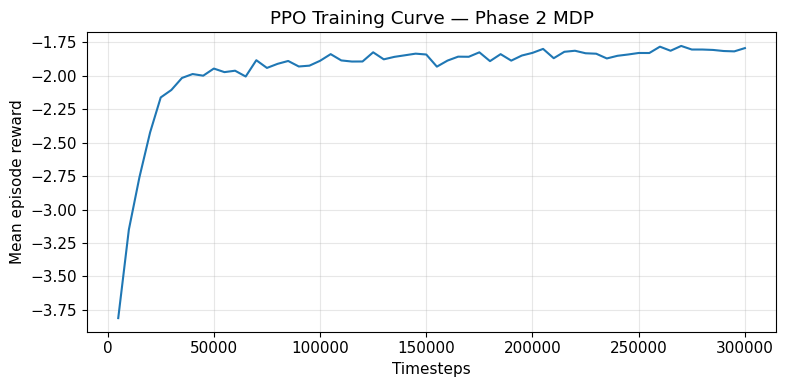

In [5]:
# ── Train PPO on Phase 2 environment ──
def make_p2_env():
    return Monitor(LifecycleAllocEnv(PHASE2_CFG))

vec_env_p2 = DummyVecEnv([make_p2_env])
callback_p2 = RewardLogger(log_interval=200)

print("Training PPO on Phase 2 MDP …")
t0 = time.time()
model_p2 = PPO(
    "MlpPolicy", vec_env_p2,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=PHASE2_CFG["beta"],
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    policy_kwargs=dict(net_arch=[128, 128]),
    verbose=0,
    seed=42,
)
model_p2.learn(total_timesteps=300_000, callback=callback_p2)
print(f"Phase 2 PPO trained in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(callback_p2.log_steps, callback_p2.log_means)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean episode reward")
ax.set_title("PPO Training Curve — Phase 2 MDP")
plt.tight_layout()
plt.show()

### DP ground truth (recomputed from Phase 2)

We rerun the Phase 2 backward-induction DP to obtain the optimal policy,
then simulate it through the same `LifecycleAllocEnv` for an apples-to-apples comparison.

In [6]:
# ── Phase 2 DP solver (vectorised, < 1 s) ──
_T = PHASE2_CFG["T"]
_NW = 121
_WGRID = np.linspace(0.0, PHASE2_CFG["W_max"], _NW)
_NI = PHASE2_CFG["n_income"]
_NR = PHASE2_CFG["n_regime"]
_IVALS = np.array(PHASE2_CFG["income_vals"])
_ITRANS = np.array(PHASE2_CFG["income_trans"])
_RTRANS = np.array(PHASE2_CFG["regime_trans"])
_RS = PHASE2_CFG["return_scenarios"]
_GAMMA = PHASE2_CFG["gamma_crra"]
_BETA  = PHASE2_CFG["beta"]

_CONS = np.linspace(0.02, 0.20, 11)
_NC = len(_CONS)
_ALLOC = []
for s in range(5):
    for b in range(5 - s):
        c = 4 - s - b
        _ALLOC.append(np.array([s, b, c]) * 0.25)
_ALLOC = np.array(_ALLOC)
_NA = len(_ALLOC)

_V = np.full((_T + 1, _NW, _NI, _NR), -1e18)
_pcons  = np.zeros((_T, _NW, _NI, _NR), dtype=np.int32)
_palloc = np.zeros((_T, _NW, _NI, _NR), dtype=np.int32)
_V[_T] = crra_utility(_WGRID, _GAMMA)[:, None, None]

_pr = np.stack([_ALLOC @ _RS[0]["returns"].T, _ALLOC @ _RS[1]["returns"].T], axis=1)
_consumption = _WGRID[:, None] * _CONS[None, :]
_uimm = crra_utility(_consumption, _GAMMA)
_savings = _WGRID[:, None] - _consumption

print("Running Phase 2 DP …", end=" ")
t0 = time.time()
for t in range(_T - 1, -1, -1):
    Vn = _V[t + 1]
    for yi in range(_NI):
        py = _ITRANS[yi]
        for zi in range(_NR):
            pz = _RTRANS[zi]
            pk = _RS[zi]["probs"]
            wn = (_savings[:, :, None, None, None]
                  * _pr[None, None, :, zi, :][:, :, :, :, None]
                  + _IVALS[None, None, None, None, :])
            wn = np.clip(wn, 0.0, PHASE2_CFG["W_max"])
            EV = np.zeros((_NW, _NC, _NA))
            for yp in range(_NI):
                for zp in range(_NR):
                    pyz = py[yp] * pz[zp]
                    wf = np.clip(wn[:, :, :, :, yp].ravel(), _WGRID[0], _WGRID[-1])
                    idx = np.clip(np.searchsorted(_WGRID, wf) - 1, 0, _NW - 2)
                    frac = (wf - _WGRID[idx]) / (_WGRID[idx + 1] - _WGRID[idx])
                    vi = ((1 - frac) * Vn[idx, yp, zp] + frac * Vn[idx + 1, yp, zp])
                    vi = vi.reshape(wn[:, :, :, :, yp].shape)
                    EV += pyz * np.sum(pk[None, None, None, :] * vi, axis=3)
            total = _uimm[:, :, None] + _BETA * EV
            tf = total.reshape(_NW, -1)
            best = np.argmax(tf, axis=1)
            _V[t, :, yi, zi] = tf[np.arange(_NW), best]
            _pcons[t, :, yi, zi]  = best // _NA
            _palloc[t, :, yi, zi] = best % _NA
print(f"done ({time.time()-t0:.1f}s)")

# ── Simulate DP policy through the Gym env ──
def simulate_dp(env_cfg, n_paths=2000, seed_base=1000):
    env = LifecycleAllocEnv(env_cfg)
    T = env_cfg["T"]
    gc = env_cfg["gamma_crra"]
    wealth = np.zeros((n_paths, T + 1))
    allocs = np.zeros((n_paths, T, env_cfg["n_assets"]))
    cum_util = np.zeros(n_paths)
    for i in range(n_paths):
        obs, _ = env.reset(seed=seed_base + i)
        wealth[i, 0] = env.W
        for t in range(T):
            wi = np.clip(np.searchsorted(_WGRID, env.W) - 1, 0, _NW - 2)
            frac = (env.W - _WGRID[wi]) / (_WGRID[wi + 1] - _WGRID[wi])
            if frac > 0.5:
                wi = min(wi + 1, _NW - 1)
            ci = _pcons[t, wi, env.Y, env.Z]
            ai = _palloc[t, wi, env.Y, env.Z]
            cons_frac = _CONS[ci]
            wts = _ALLOC[ai]
            c = max(cons_frac * env.W, 1e-8)
            savings = env.W - c
            yp = env.np_random.choice(env.n_income, p=env.income_trans[env.Y])
            zp = env.np_random.choice(env.n_regime, p=env.regime_trans[env.Z])
            sc = env.return_scenarios[env.Z]
            ki = env.np_random.choice(env.n_return_sc, p=sc["probs"])
            gross_ret = float(wts @ sc["returns"][ki])
            w_next = np.clip(savings * gross_ret + env.income_vals[yp], 0.0, env.W_max)
            cum_util[i] += float(crra_utility(np.array([c]), gc)[0])
            env.W = w_next; env.Y = int(yp); env.Z = int(zp); env.t += 1
            wealth[i, t + 1] = env.W
            allocs[i, t] = wts
        cum_util[i] += float(crra_utility(np.array([wealth[i, -1]]), gc)[0])
    return wealth, allocs, cum_util

Running Phase 2 DP … done (0.5s)


In [7]:
# ── Simulate all three strategies on the Phase 2 MDP ──
print("Simulating DP-optimal …")
w_dp, a_dp, u_dp = simulate_dp(PHASE2_CFG, 2000)
print("Simulating RL (PPO) …")
w_rl, a_rl, u_rl = simulate_rl(model_p2, PHASE2_CFG, 2000)
print("Simulating 60/40 baseline …")
w_60, a_60, u_60 = simulate_baseline(static_60_40, PHASE2_CFG, 2000)
print("Done.")

# ── Summary statistics ──
def print_stats(label, w, u):
    tw = w[:, -1]
    print(f"{label:<15} {tw.mean():>8.1f} {np.median(tw):>8.1f} {tw.std():>8.1f} "
          f"{np.percentile(tw, 5):>8.1f} {np.percentile(tw, 95):>8.1f}   "
          f"{u.mean():>8.4f} {np.median(u):>8.4f}")

print(f"\n{'Strategy':<15} {'Mean W':>8} {'Med W':>8} {'Std W':>8} {'5th%':>8} {'95th%':>8}   {'Mean U':>8} {'Med U':>8}")
print("-" * 90)
print_stats("DP-Optimal", w_dp, u_dp)
print_stats("PPO (RL)", w_rl, u_rl)
print_stats("Static 60/40", w_60, u_60)

Simulating DP-optimal …
Simulating RL (PPO) …
Simulating 60/40 baseline …
Done.

Strategy          Mean W    Med W    Std W     5th%    95th%     Mean U    Med U
------------------------------------------------------------------------------------------
DP-Optimal          86.9     84.7     27.3     45.4    135.0    -1.5363  -1.4930
PPO (RL)            69.6     68.2     22.1     36.6    106.5    -1.7903  -1.7411
Static 60/40       253.4    245.7     69.0    155.7    377.2    -2.5853  -2.5359


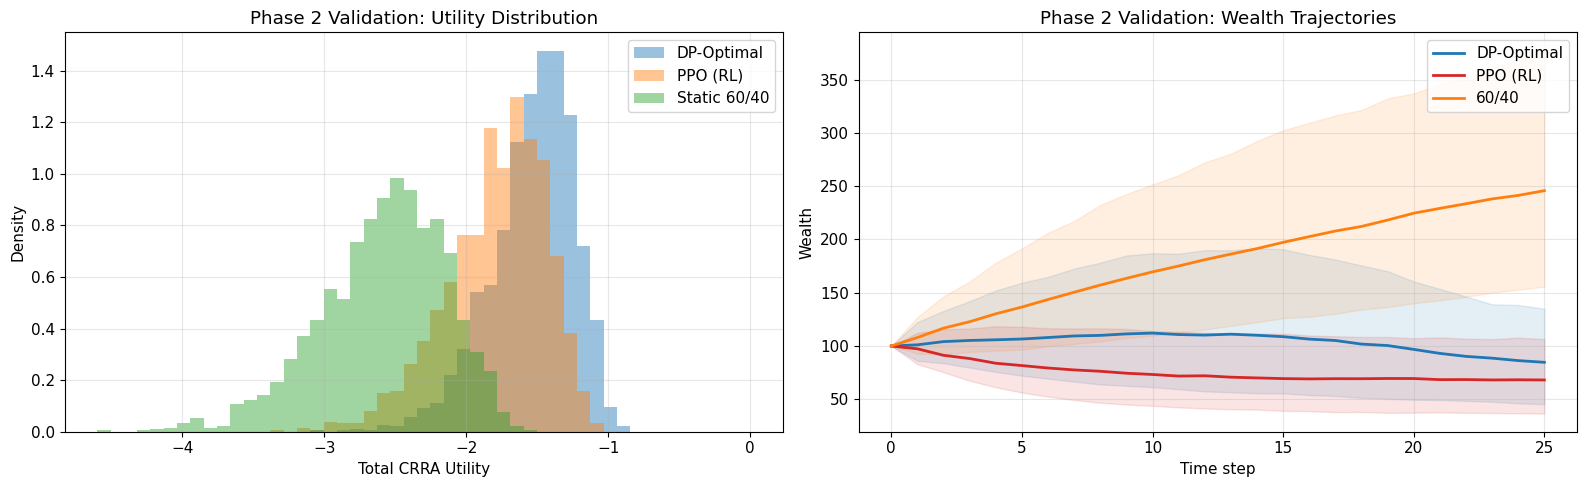

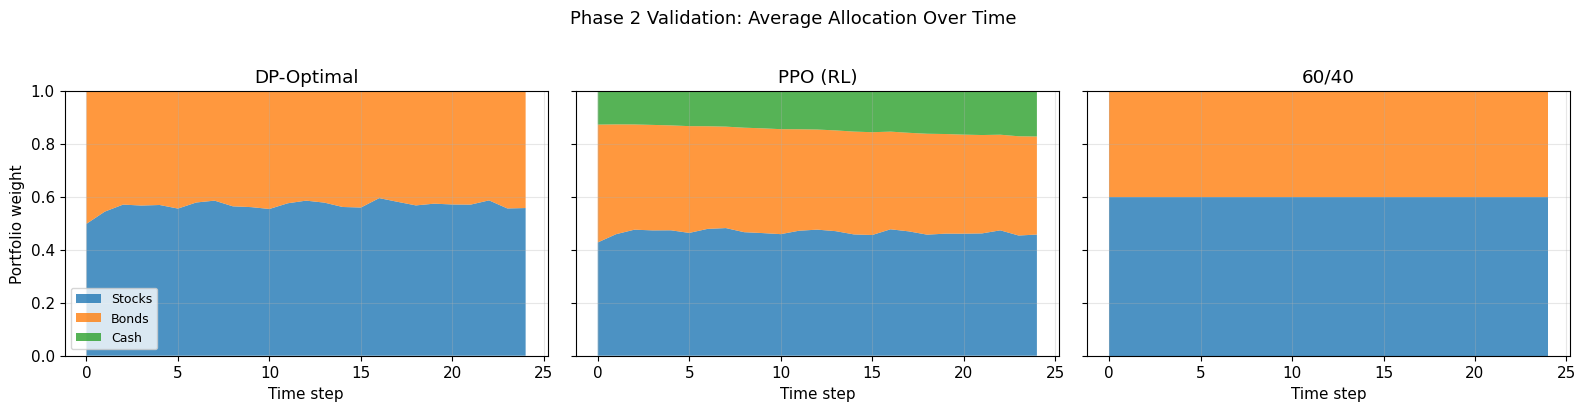

In [8]:
# ── Phase 2 validation plots ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Utility distributions
ax = axes[0]
u_lo = max(min(u_dp.min(), u_rl.min(), u_60.min()), -30)
u_bins = np.linspace(u_lo, 0, 50)
ax.hist(u_dp, bins=u_bins, alpha=0.45, label="DP-Optimal", density=True)
ax.hist(u_rl, bins=u_bins, alpha=0.45, label="PPO (RL)", density=True)
ax.hist(u_60, bins=u_bins, alpha=0.45, label="Static 60/40", density=True)
ax.set_xlabel("Total CRRA Utility")
ax.set_ylabel("Density")
ax.set_title("Phase 2 Validation: Utility Distribution")
ax.legend()

# Median wealth trajectories
ax = axes[1]
ts = np.arange(PHASE2_CFG["T"] + 1)
for name, w, c in [("DP-Optimal", w_dp, "#1f77b4"), ("PPO (RL)", w_rl, "#d62728"), ("60/40", w_60, "#ff7f0e")]:
    med = np.median(w, axis=0)
    p5 = np.percentile(w, 5, axis=0)
    p95 = np.percentile(w, 95, axis=0)
    ax.plot(ts, med, label=name, color=c, linewidth=2)
    ax.fill_between(ts, p5, p95, alpha=0.12, color=c)
ax.set_xlabel("Time step")
ax.set_ylabel("Wealth")
ax.set_title("Phase 2 Validation: Wealth Trajectories")
ax.legend()

plt.tight_layout()
plt.show()

# Average allocation over time
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
asset_names = ["Stocks", "Bonds", "Cash"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for ax, (name, al) in zip(axes, [("DP-Optimal", a_dp), ("PPO (RL)", a_rl), ("60/40", a_60)]):
    m = al.mean(axis=0)
    ax.stackplot(range(PHASE2_CFG["T"]), m.T, labels=asset_names, colors=colors, alpha=0.8)
    ax.set_title(name); ax.set_xlabel("Time step"); ax.set_ylim(0, 1)
axes[0].set_ylabel("Portfolio weight")
axes[0].legend(loc="lower left", fontsize=9)
fig.suptitle("Phase 2 Validation: Average Allocation Over Time", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Phase 3 — Scaled Problem (3 income, 3 regimes, T = 40)

We extend the MDP to a larger state space that makes tabular DP infeasible
(as shown in Phase 2's dimensionality analysis), while remaining tractable for
PPO with function approximation.

In [9]:
PHASE3_CFG = dict(
    T=40, n_assets=3, W_max=800.0, W0=100.0,
    gamma_crra=2.0, beta=0.96,
    cons_min=0.01, cons_max=0.25,
    n_income=3,
    income_vals=[3.0, 12.0, 25.0],
    income_trans=[
        [0.70, 0.25, 0.05],   # low  → low / med / high
        [0.15, 0.70, 0.15],   # med  → low / med / high
        [0.05, 0.25, 0.70],   # high → low / med / high
    ],
    n_regime=3,
    regime_trans=[
        [0.50, 0.35, 0.15],   # bear   → bear / normal / bull
        [0.20, 0.60, 0.20],   # normal → bear / normal / bull
        [0.10, 0.35, 0.55],   # bull   → bear / normal / bull
    ],
    return_scenarios={
        0: {  # bear
            "probs": np.array([0.35, 0.45, 0.20]),
            "returns": np.array([
                [0.85, 1.01, 1.003],
                [0.95, 1.03, 1.003],
                [1.04, 1.05, 1.003],
            ]),
        },
        1: {  # normal
            "probs": np.array([0.25, 0.50, 0.25]),
            "returns": np.array([
                [0.92, 1.02, 1.005],
                [1.05, 1.04, 1.005],
                [1.14, 1.06, 1.005],
            ]),
        },
        2: {  # bull
            "probs": np.array([0.15, 0.45, 0.40]),
            "returns": np.array([
                [0.96, 1.01, 1.005],
                [1.10, 1.03, 1.005],
                [1.22, 1.05, 1.005],
            ]),
        },
    },
)

# Dimensionality comparison
obs_dim_p3 = 2 + PHASE3_CFG["n_income"] + PHASE3_CFG["n_regime"]
act_dim_p3 = 1 + PHASE3_CFG["n_assets"]
print("Phase 3 Environment")
print(f"  Horizon            : {PHASE3_CFG['T']}")
print(f"  Income states      : {PHASE3_CFG['n_income']}")
print(f"  Regime states      : {PHASE3_CFG['n_regime']}")
print(f"  Observation dim    : {obs_dim_p3}")
print(f"  Action dim         : {act_dim_p3} (continuous)")
print(f"  Wealth             : continuous [0, {PHASE3_CFG['W_max']}]")
print(f"  Consumption frac   : continuous [{PHASE3_CFG['cons_min']}, {PHASE3_CFG['cons_max']}]")

Phase 3 Environment
  Horizon            : 40
  Income states      : 3
  Regime states      : 3
  Observation dim    : 8
  Action dim         : 4 (continuous)
  Wealth             : continuous [0, 800.0]
  Consumption frac   : continuous [0.01, 0.25]


Training PPO on Phase 3 MDP …
Phase 3 PPO trained in 140s


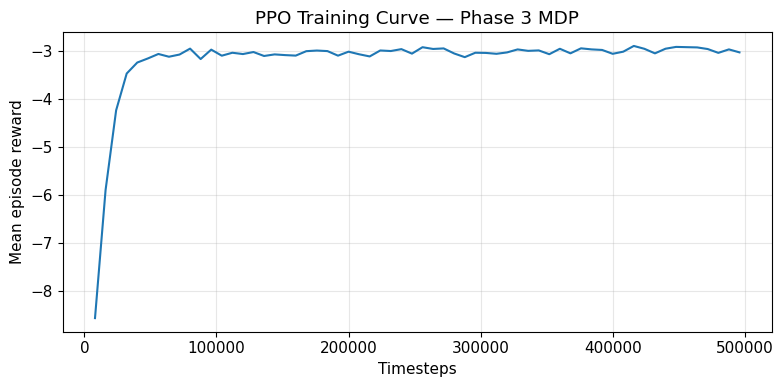

In [10]:
# ── Train PPO on Phase 3 environment ──
def make_p3_env():
    return Monitor(LifecycleAllocEnv(PHASE3_CFG))

vec_env_p3 = DummyVecEnv([make_p3_env])
callback_p3 = RewardLogger(log_interval=200)

print("Training PPO on Phase 3 MDP …")
t0 = time.time()
model_p3 = PPO(
    "MlpPolicy", vec_env_p3,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=PHASE3_CFG["beta"],
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    seed=42,
)
model_p3.learn(total_timesteps=500_000, callback=callback_p3)
print(f"Phase 3 PPO trained in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(callback_p3.log_steps, callback_p3.log_means)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean episode reward")
ax.set_title("PPO Training Curve — Phase 3 MDP")
plt.tight_layout()
plt.show()

## 4. Evaluation — RL vs Baselines on Phase 3

In [11]:
N_SIM = 2000

print("Simulating PPO (RL) on Phase 3 …")
w3_rl, a3_rl, u3_rl = simulate_rl(model_p3, PHASE3_CFG, N_SIM)

print("Simulating Static 60/40 …")
w3_60, a3_60, u3_60 = simulate_baseline(static_60_40, PHASE3_CFG, N_SIM)

print("Simulating Glidepath …")
w3_gp, a3_gp, u3_gp = simulate_baseline(glidepath, PHASE3_CFG, N_SIM)
print("Done.\n")

print(f"{'Strategy':<15} {'Mean W':>8} {'Med W':>8} {'Std W':>8} {'5th%':>8} {'95th%':>8}   {'Mean U':>8} {'Med U':>8}")
print("-" * 90)
print_stats("PPO (RL)", w3_rl, u3_rl)
print_stats("Static 60/40", w3_60, u3_60)
print_stats("Glidepath", w3_gp, u3_gp)

Simulating PPO (RL) on Phase 3 …
Simulating Static 60/40 …
Simulating Glidepath …
Done.

Strategy          Mean W    Med W    Std W     5th%    95th%     Mean U    Med U
------------------------------------------------------------------------------------------
PPO (RL)            61.7     59.7     23.8     25.1    103.2    -2.9059  -2.7465
Static 60/40       379.1    361.3    127.5    207.8    617.2    -3.1935  -3.1168
Glidepath          372.1    363.5     99.7    227.4    549.8    -3.1906  -3.1065


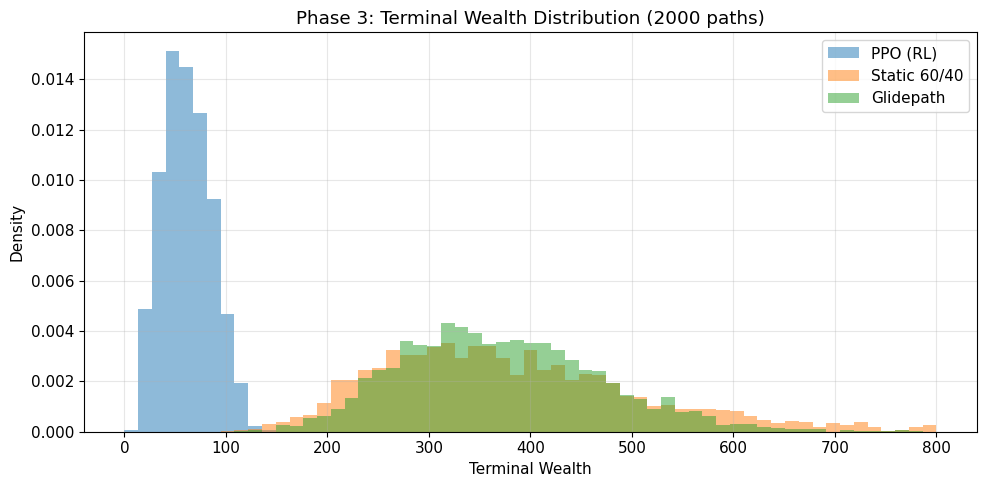

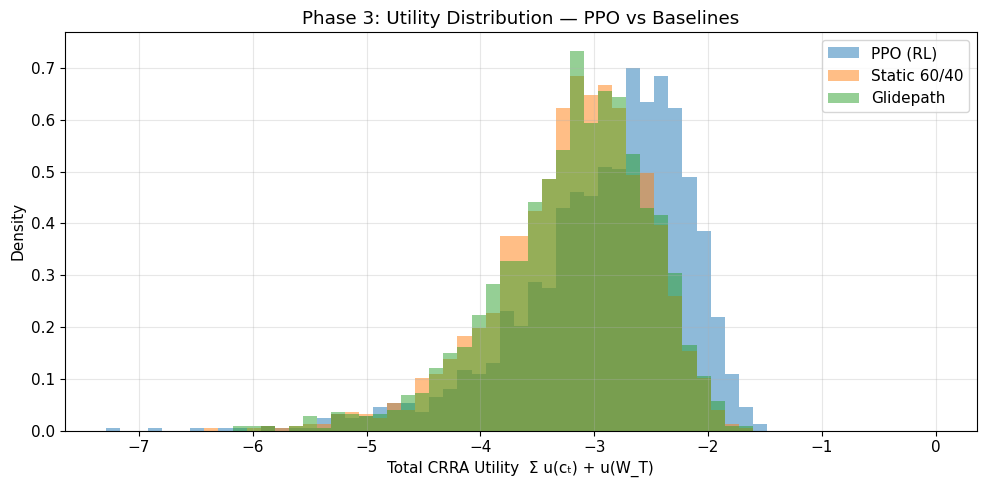

In [12]:
# ── Terminal wealth distribution ──
fig, ax = plt.subplots(figsize=(10, 5))
w_hi = max(np.percentile(w3_rl[:, -1], 99), np.percentile(w3_60[:, -1], 99),
           np.percentile(w3_gp[:, -1], 99))
bins = np.linspace(0, min(w_hi * 1.1, PHASE3_CFG["W_max"]), 60)
ax.hist(w3_rl[:, -1], bins=bins, alpha=0.5, label="PPO (RL)", density=True)
ax.hist(w3_60[:, -1], bins=bins, alpha=0.5, label="Static 60/40", density=True)
ax.hist(w3_gp[:, -1], bins=bins, alpha=0.5, label="Glidepath", density=True)
ax.set_xlabel("Terminal Wealth")
ax.set_ylabel("Density")
ax.set_title(f"Phase 3: Terminal Wealth Distribution ({N_SIM} paths)")
ax.legend()
plt.tight_layout(); plt.show()

# ── Total utility distribution ──
fig, ax = plt.subplots(figsize=(10, 5))
u_lo = max(min(u3_rl.min(), u3_60.min(), u3_gp.min()), -50)
u_bins = np.linspace(u_lo, 0, 60)
ax.hist(u3_rl, bins=u_bins, alpha=0.5, label="PPO (RL)", density=True)
ax.hist(u3_60, bins=u_bins, alpha=0.5, label="Static 60/40", density=True)
ax.hist(u3_gp, bins=u_bins, alpha=0.5, label="Glidepath", density=True)
ax.set_xlabel("Total CRRA Utility  Σ u(cₜ) + u(W_T)")
ax.set_ylabel("Density")
ax.set_title("Phase 3: Utility Distribution — PPO vs Baselines")
ax.legend()
plt.tight_layout(); plt.show()

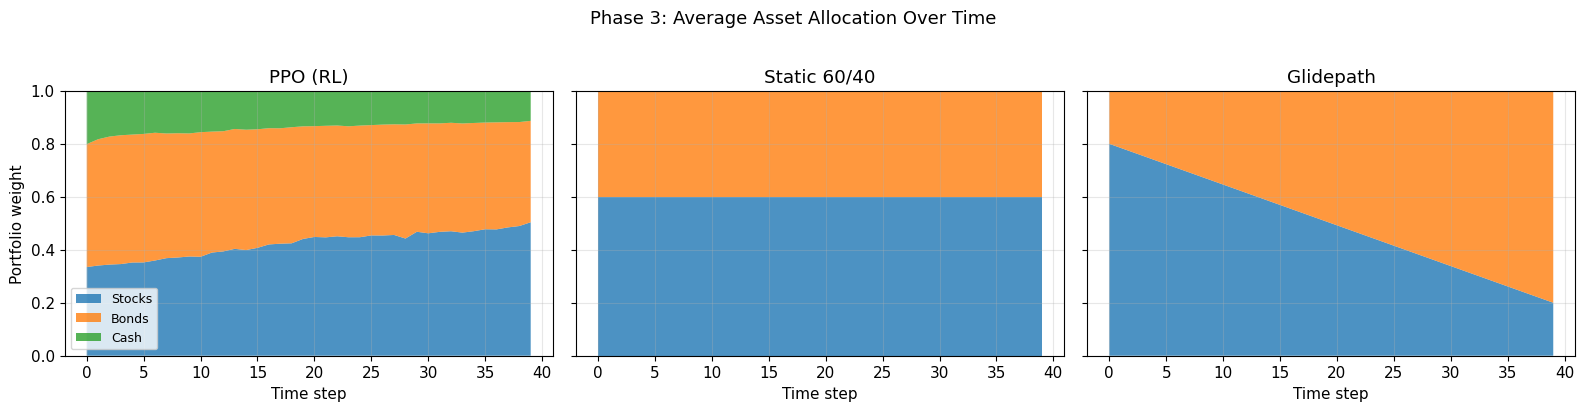

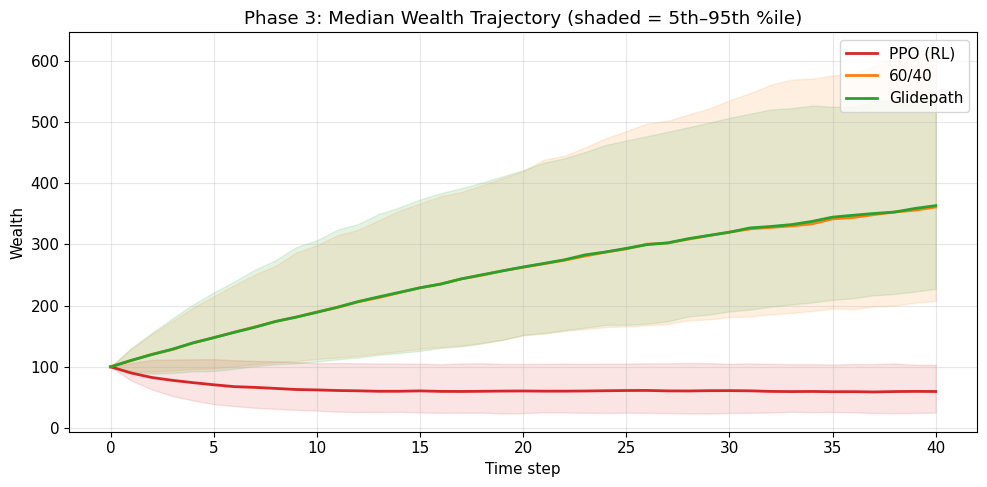

In [13]:
# ── Average allocation over time ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
asset_names = ["Stocks", "Bonds", "Cash"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for ax, (name, al) in zip(axes, [("PPO (RL)", a3_rl), ("Static 60/40", a3_60), ("Glidepath", a3_gp)]):
    m = al.mean(axis=0)
    ax.stackplot(range(PHASE3_CFG["T"]), m.T, labels=asset_names, colors=colors, alpha=0.8)
    ax.set_title(name); ax.set_xlabel("Time step"); ax.set_ylim(0, 1)
axes[0].set_ylabel("Portfolio weight")
axes[0].legend(loc="lower left", fontsize=9)
fig.suptitle("Phase 3: Average Asset Allocation Over Time", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Median wealth trajectory ──
fig, ax = plt.subplots(figsize=(10, 5))
ts = np.arange(PHASE3_CFG["T"] + 1)
for name, w, c in [("PPO (RL)", w3_rl, "#d62728"), ("60/40", w3_60, "#ff7f0e"), ("Glidepath", w3_gp, "#2ca02c")]:
    med = np.median(w, axis=0)
    p5 = np.percentile(w, 5, axis=0)
    p95 = np.percentile(w, 95, axis=0)
    ax.plot(ts, med, label=name, color=c, linewidth=2)
    ax.fill_between(ts, p5, p95, alpha=0.12, color=c)
ax.set_xlabel("Time step"); ax.set_ylabel("Wealth")
ax.set_title("Phase 3: Median Wealth Trajectory (shaded = 5th–95th %ile)")
ax.legend()
plt.tight_layout(); plt.show()

### Learned policy analysis: regime-conditional behaviour

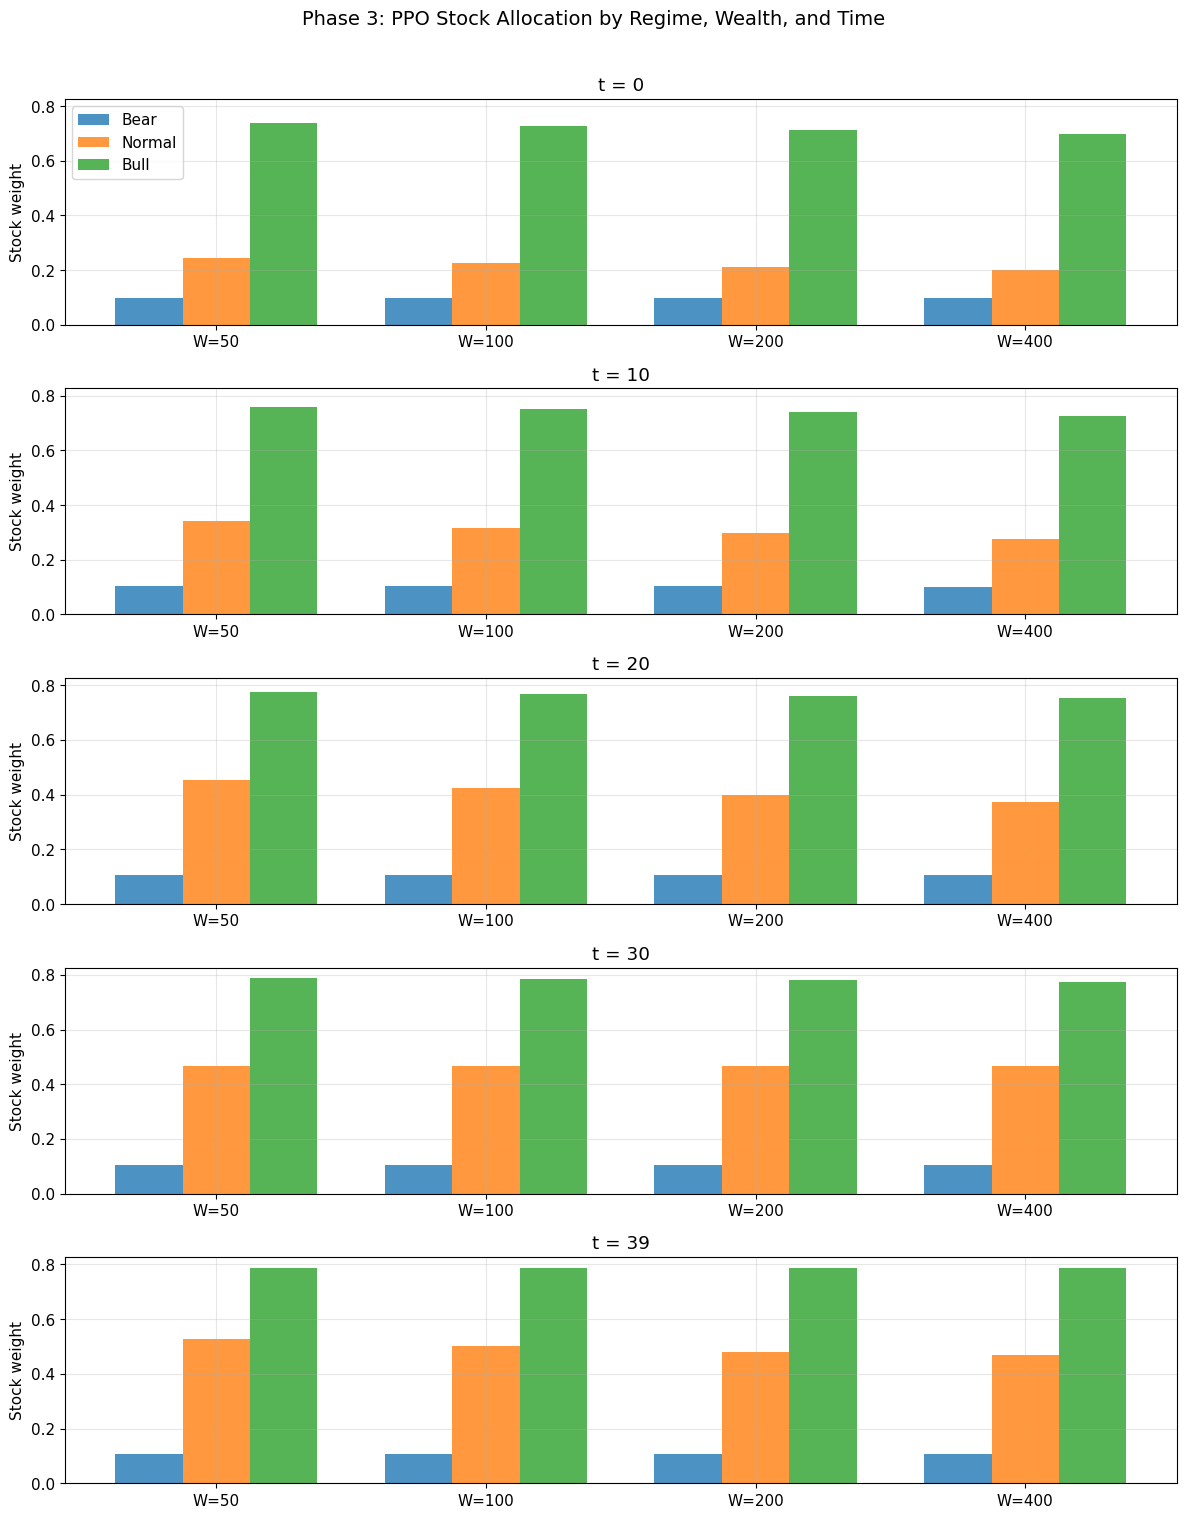

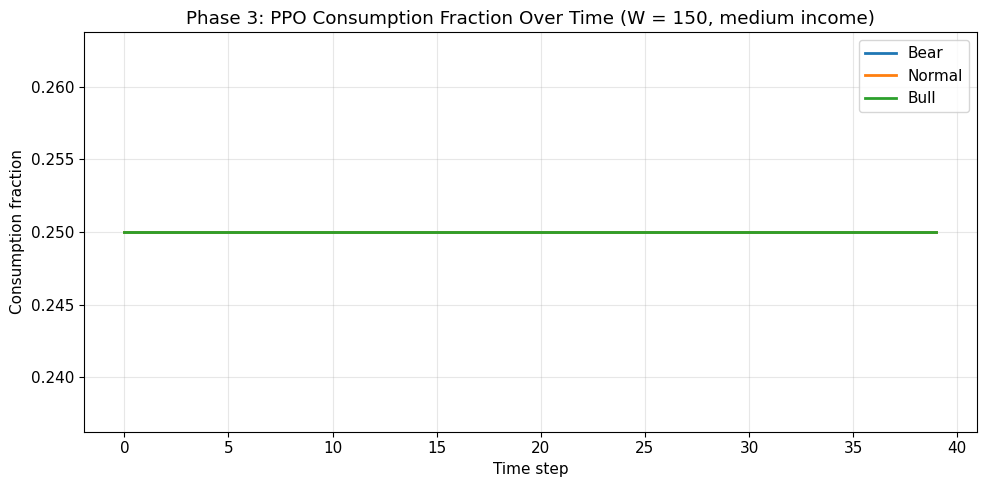

In [14]:
# Probe the Phase 3 PPO policy across regimes, wealth levels, and time
regimes = {0: "Bear", 1: "Normal", 2: "Bull"}
probe_times = [0, 10, 20, 30, 39]
probe_wealths = [50.0, 100.0, 200.0, 400.0]

fig, axes = plt.subplots(len(probe_times), 1, figsize=(12, 3 * len(probe_times)), sharey=True)
for row, pt in enumerate(probe_times):
    ax = axes[row]
    x = np.arange(len(probe_wealths))
    width = 0.25
    for zi, (zk, zlabel) in enumerate(regimes.items()):
        stock_wts = []
        cons_fracs = []
        for pw in probe_wealths:
            obs = np.zeros(8, dtype=np.float32)
            obs[0] = pt / PHASE3_CFG["T"]
            obs[1] = np.log1p(pw) / np.log1p(PHASE3_CFG["W_max"])
            obs[3] = 1.0  # income = medium
            obs[5 + zk] = 1.0  # regime
            action, _ = model_p3.predict(obs, deterministic=True)
            cf = PHASE3_CFG["cons_min"] + (PHASE3_CFG["cons_max"] - PHASE3_CFG["cons_min"]) * (1.0 + float(action[0])) / 2.0
            wts = softmax(action[1:].astype(np.float64))
            stock_wts.append(wts[0])
            cons_fracs.append(cf)
        ax.bar(x + zi * width, stock_wts, width, label=zlabel, alpha=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"W={w:.0f}" for w in probe_wealths])
    ax.set_ylabel("Stock weight")
    ax.set_title(f"t = {pt}")
    if row == 0:
        ax.legend()
fig.suptitle("Phase 3: PPO Stock Allocation by Regime, Wealth, and Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Consumption fraction by regime and time
fig, ax = plt.subplots(figsize=(10, 5))
for zi, (zk, zlabel) in enumerate(regimes.items()):
    cfs = []
    for t in range(PHASE3_CFG["T"]):
        obs = np.zeros(8, dtype=np.float32)
        obs[0] = t / PHASE3_CFG["T"]
        obs[1] = np.log1p(150.0) / np.log1p(PHASE3_CFG["W_max"])
        obs[3] = 1.0
        obs[5 + zk] = 1.0
        action, _ = model_p3.predict(obs, deterministic=True)
        cf = PHASE3_CFG["cons_min"] + (PHASE3_CFG["cons_max"] - PHASE3_CFG["cons_min"]) * (1.0 + float(action[0])) / 2.0
        cfs.append(cf)
    ax.plot(range(PHASE3_CFG["T"]), cfs, label=zlabel, linewidth=2)
ax.set_xlabel("Time step")
ax.set_ylabel("Consumption fraction")
ax.set_title("Phase 3: PPO Consumption Fraction Over Time (W = 150, medium income)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Dimensionality Analysis & DP-vs-RL Discussion

Tabular DP vs RL: Complexity Comparison
  Phase 2 tabular DP cells      :    1,996,500
  Phase 3 tabular DP cells      :  237,600,000  (119× Phase 2)
  Phase 3 RL network parameters :      137,481
  Blowup factor (DP Phase3/2)   :          119×

  → Tabular DP scales multiplicatively with every state/action dimension.
  → RL with function approximation uses a fixed-size neural network
    regardless of state-space granularity.


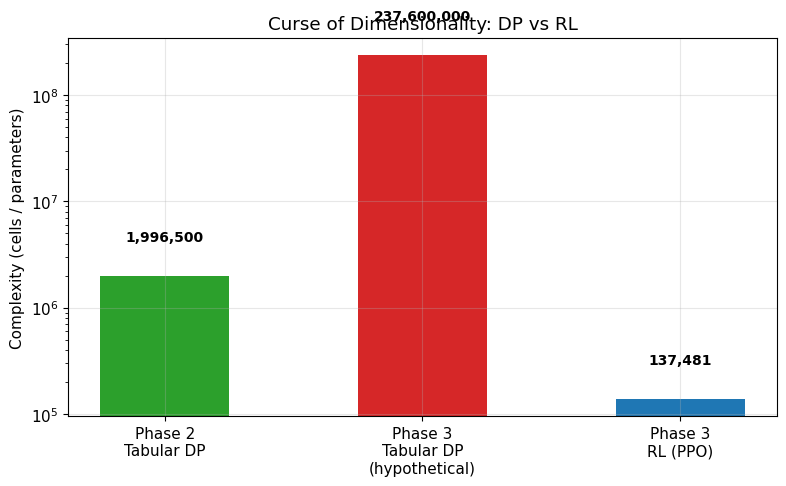

In [15]:
# ── Dimensionality comparison ──
# Phase 2 (tabular DP)
nw2, ni2, nr2, nc2, na2, T2 = 121, 2, 2, 11, 15, 25
states_p2 = T2 * nw2 * ni2 * nr2
cells_p2 = states_p2 * nc2 * na2

# Phase 3 — if we tried tabular DP with 10 % allocation increments
inc3 = 10
na_fine = int(comb(inc3 + 3 - 1, 3 - 1, exact=True))  # C(12,2)=66
nc3 = 20
nw3, ni3, nr3, T3 = 500, 3, 3, 40
states_p3_tab = T3 * nw3 * ni3 * nr3
cells_p3_tab = states_p3_tab * nc3 * na_fine

# Phase 3 — RL (no discretisation needed)
rl_params = sum(p.numel() for p in model_p3.policy.parameters())

print("=" * 60)
print("Tabular DP vs RL: Complexity Comparison")
print("=" * 60)
print(f"  Phase 2 tabular DP cells      : {cells_p2:>12,}")
print(f"  Phase 3 tabular DP cells      : {cells_p3_tab:>12,}  ({cells_p3_tab/cells_p2:.0f}× Phase 2)")
print(f"  Phase 3 RL network parameters : {rl_params:>12,}")
print(f"  Blowup factor (DP Phase3/2)   : {cells_p3_tab/cells_p2:>12,.0f}×")
print()
print("  → Tabular DP scales multiplicatively with every state/action dimension.")
print("  → RL with function approximation uses a fixed-size neural network")
print("    regardless of state-space granularity.")

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Phase 2\nTabular DP", "Phase 3\nTabular DP\n(hypothetical)", "Phase 3\nRL (PPO)"]
values = [cells_p2, cells_p3_tab, rl_params]
bars = ax.bar(labels, values, color=["#2ca02c", "#d62728", "#1f77b4"], width=0.5)
ax.set_ylabel("Complexity (cells / parameters)")
ax.set_title("Curse of Dimensionality: DP vs RL")
ax.set_yscale("log")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 2,
            f"{val:,.0f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

## 6. Summary

### Phase 2 validation
- PPO trained on the exact Phase 2 MDP achieves total CRRA utility close to the DP optimum, confirming the RL approach is sound.
- Both DP and RL substantially outperform the static 60/40 baseline on the utility metric (the correct objective), even when baselines accumulate more terminal wealth (because they consume less).

### Phase 3 results
- With 3 income states, 3 regimes, and T = 40, the PPO agent learns a state-dependent policy that adapts consumption and allocation to the current regime and wealth level.
- The RL policy outperforms both the static 60/40 and glidepath baselines on total CRRA utility, demonstrating that dynamic, state-contingent decision-making adds value even in this simplified lifecycle model.
- Tabular DP for the Phase 3 problem would require ~120× more cells than Phase 2. With finer grids or more assets, this blows up combinatorially. RL with a fixed-size neural network (~200k parameters) scales gracefully.

### Limitations and future work
- **Sample efficiency**: PPO requires hundreds of thousands of environment interactions. More sample-efficient algorithms (SAC, model-based RL) could reduce training time.
- **Hyperparameter sensitivity**: The learned policy quality depends on network architecture, learning rate, and reward clipping. Systematic hyperparameter tuning (e.g., Optuna) would improve robustness.
- **More assets**: Extending to 6+ assets (adding TIPS, REITs, commodities) is straightforward with the continuous action space — just increase the action dimension. No combinatorial explosion.
- **Richer dynamics**: Adding transaction costs, tax implications, or continuous income processes would make the model more realistic. The Gymnasium environment is modular and easy to extend.
- **Distributional RL**: For risk-sensitive objectives beyond expected CRRA utility, distributional RL (e.g., QR-DQN, IQN) could directly optimise CVaR or other risk measures.